# DSCI 552 — Homework 2

**Name:** Pooja Nandyappa Subashchandra

**GitHub Username:** nandyapp-afk

**USC ID:** 1768721225

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## (a) Download Data

In [2]:
df = pd.read_excel("data/Folds5x2_pp.xlsx", sheet_name="Sheet1")
print(df.shape)
df.head()

(9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## (b) Exploring the Data

### i. Rows and columns

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()
print(df.dtypes)

Rows: 9568
Columns: 5

AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object


**Rows:** 9568. Each row is one hourly average measurement from a Combined
Cycle Power Plant, collected over six years (2006–2011) while the plant was
operating at full load.

**Columns:** 5. Four are ambient predictor variables and one is the response:

| Column | Variable | Units | Role |
|---|---|---|---|
| AT | Ambient temperature | °C | predictor |
| V | Exhaust vacuum | cm Hg | predictor |
| AP | Ambient pressure | millibar | predictor |
| RH | Relative humidity | % | predictor |
| PE | Net hourly electrical energy output | MW | **response** |

There are no missing values. The goal is to predict PE from the four ambient
variables.

### ii. Pairwise scatterplots

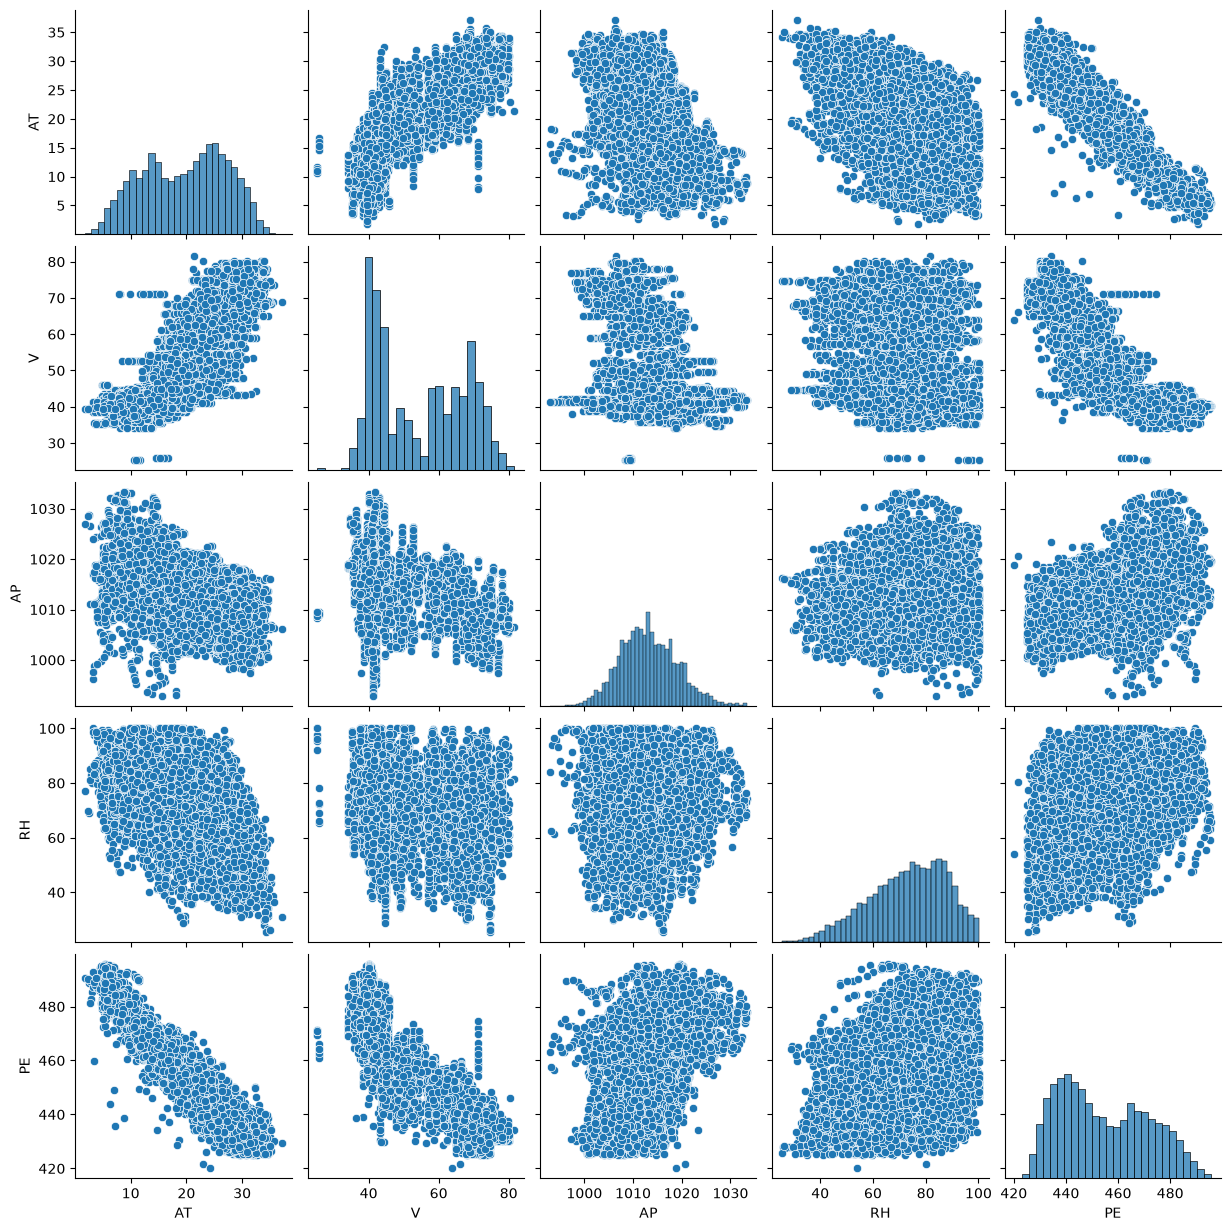

In [4]:
sns.pairplot(df)
plt.show()

**Findings.** All four predictors show a monotone relationship with PE:

| Predictor | Direction | Correlation with PE | Strength |
|---|---|---|---|
| AT | negative | −0.948 | very strong, nearly linear |
| V | negative | −0.870 | strong |
| AP | positive | +0.518 | moderate |
| RH | positive | +0.390 | weak |

Ambient temperature is by far the strongest predictor: power output falls
almost linearly as temperature rises, which is physically expected since
warmer air is less dense and reduces gas turbine efficiency. Exhaust vacuum
behaves similarly. Ambient pressure and relative humidity are positively
associated with output but much more diffuse.

The predictors are also correlated with one another. Most notably AT and V
have a correlation of +0.844, and AT is moderately correlated with both AP
(−0.508) and RH (−0.543). This collinearity is relevant to parts (d) and (e),
since a predictor's coefficient in a multiple regression can differ
substantially from its coefficient in a simple regression when predictors
share information.

### iii. Summary statistics

In [5]:
summary = df.describe().T[["mean", "50%", "min", "max", "25%", "75%"]]
summary.columns = ["Mean", "Median", "Min", "Max", "Q1", "Q3"]
summary["Range"] = summary["Max"] - summary["Min"]
summary["IQR"] = summary["Q3"] - summary["Q1"]
print(summary.round(3).to_string())

        Mean    Median     Min      Max        Q1       Q3  Range     IQR
AT    19.651    20.345    1.81    37.11    13.510    25.72  35.30  12.210
V     54.306    52.080   25.36    81.56    41.740    66.54  56.20  24.800
AP  1013.259  1012.940  992.89  1033.30  1009.100  1017.26  40.41   8.160
RH    73.309    74.975   25.56   100.16    63.328    84.83  74.60  21.502
PE   454.365   451.550  420.26   495.76   439.750   468.43  75.50  28.680


In [6]:
X = sm.add_constant(df[["AT"]])
model_AT = sm.OLS(df["PE"], X).fit()
print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:56:36   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        497.0341      0.156   3177.280      0.0

## (c) Simple Linear Regression

In [7]:
simple_results = {}

for p in ["AT", "V", "AP", "RH"]:
    X = sm.add_constant(df[[p]])
    m = sm.OLS(df["PE"], X).fit()
    simple_results[p] = m
    print(f"{p}:  coef = {m.params[p]:.4f}   "
          f"p-value = {m.pvalues[p]:.3e}   R² = {m.rsquared:.4f}")

AT:  coef = -2.1713   p-value = 0.000e+00   R² = 0.8989
V:  coef = -1.1681   p-value = 0.000e+00   R² = 0.7565
AP:  coef = 1.4899   p-value = 0.000e+00   R² = 0.2688
RH:  coef = 0.4557   p-value = 0.000e+00   R² = 0.1519


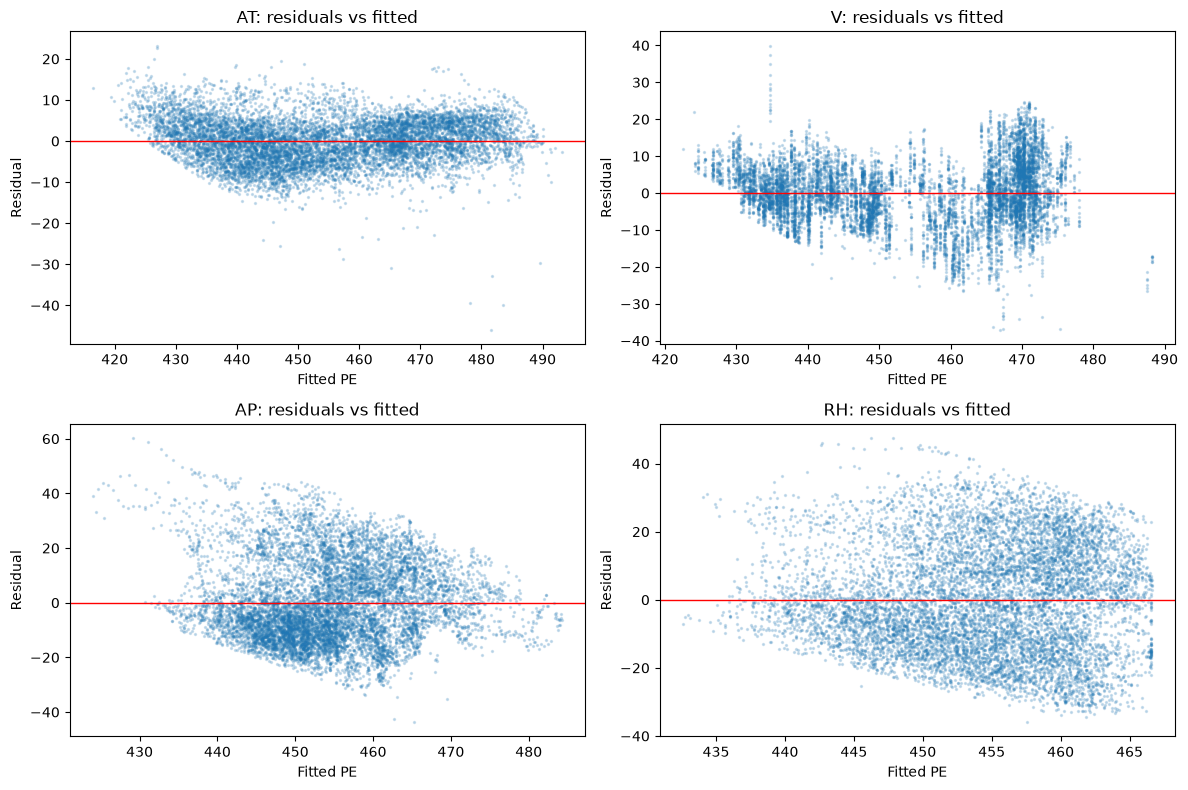

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, p in zip(axes.ravel(), ["AT", "V", "AP", "RH"]):
    m = simple_results[p]
    ax.scatter(m.fittedvalues, m.resid, s=2, alpha=0.2)
    ax.axhline(0, color="red", lw=1)
    ax.set_title(f"{p}: residuals vs fitted")
    ax.set_xlabel("Fitted PE")
    ax.set_ylabel("Residual")
fig.tight_layout()
plt.show()

In [9]:
for p in ["AT", "V", "AP", "RH"]:
    r = simple_results[p].resid
    print(f"{p}: {(abs(r) > 3 * r.std()).sum()} residuals beyond 3 SD")

AT: 42 residuals beyond 3 SD
V: 33 residuals beyond 3 SD
AP: 28 residuals beyond 3 SD
RH: 2 residuals beyond 3 SD


**Results.** A simple linear regression was fit for each predictor separately.

| Predictor | Coefficient | p-value | R² |
|---|---|---|---|
| AT | −2.1713 | < 0.001 | 0.8989 |
| V | −1.1681 | < 0.001 | 0.7565 |
| AP | +1.4899 | < 0.001 | 0.2688 |
| RH | +0.4557 | < 0.001 | 0.1519 |

**Statistical significance.** In all four models the p-value for the slope is
below machine precision, far under the 0.05 threshold, so H₀: β₁ = 0 is
rejected in every case. Each predictor has a statistically significant
association with PE.

Significance and explanatory power are distinct, however. RH explains only
15% of the variance in PE yet is still highly significant, because with
n = 9568 observations even a weak association is detectable. AT is both
significant and strong, explaining roughly 90% of the variance on its own.

The signs match the scatterplots in (b)ii: AT and V are negatively associated
with output, AP and RH positively.

**Residual plots.** Residuals versus fitted values were plotted for each
model. The AT and V models show a shallow U-shaped pattern in the residuals
rather than a flat band, indicating that a straight line is not quite the
correct functional form and that some curvature remains unmodeled. This is
examined directly in part (f).

**Outliers.** Each model has a small number of points with residuals beyond
three standard deviations (42 for AT, 33 for V, 28 for AP, 2 for RH), which
is at most 0.4% of 9568 observations. These were not removed. There is no
evidence that they are recording errors rather than genuine unusual operating
conditions, and discarding observations solely because they fit the model
poorly would bias the results.

## (d) Multiple Regression

In [10]:
predictors = ["AT", "V", "AP", "RH"]

X_multi = sm.add_constant(df[predictors])
model_multi = sm.OLS(df["PE"], X_multi).fit()
print(model_multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:56:36   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

**Results.** A multiple regression of PE on all four predictors gives
R² = 0.929, up from 0.899 for AT alone.

| Predictor | Coefficient | p-value |
|---|---|---|
| Intercept | 454.6093 | < 0.001 |
| AT | −1.9775 | < 0.001 |
| V | −0.2339 | < 0.001 |
| AP | +0.0621 | < 0.001 |
| RH | −0.1581 | < 0.001 |

**Null hypothesis.** All four p-values are below 0.001, so H₀: βⱼ = 0 is
rejected for every predictor. Each contributes significantly to the model
even after accounting for the other three.

Each coefficient is now a partial effect: the expected change in PE per unit
increase in that predictor while the other three are held fixed. AT remains
the dominant predictor at roughly −1.98 MW per °C.

## (e) Comparing Coefficients

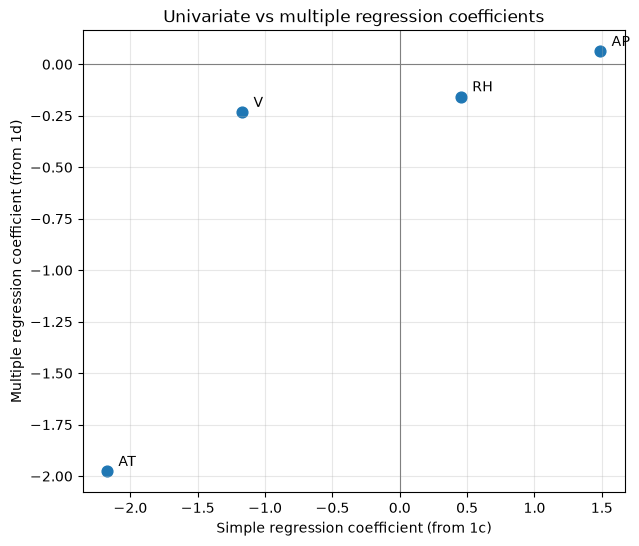

In [11]:
simple_coefs = [simple_results[p].params[p] for p in predictors]
multi_coefs = [model_multi.params[p] for p in predictors]

plt.figure(figsize=(7, 6))
plt.scatter(simple_coefs, multi_coefs, s=60)

for p, x, y in zip(predictors, simple_coefs, multi_coefs):
    plt.annotate(p, (x, y), textcoords="offset points", xytext=(8, 4))

plt.axhline(0, color="gray", lw=0.8)
plt.axvline(0, color="gray", lw=0.8)
plt.xlabel("Simple regression coefficient (from 1c)")
plt.ylabel("Multiple regression coefficient (from 1d)")
plt.title("Univariate vs multiple regression coefficients")
plt.grid(alpha=0.3)
plt.show()

**Comparison.** The coefficients differ substantially between the two
approaches:

| Predictor | Simple (1c) | Multiple (1d) |
|---|---|---|
| AT | −2.1713 | −1.9775 |
| V | −1.1681 | −0.2339 |
| AP | +1.4899 | +0.0621 |
| RH | +0.4557 | **−0.1581** |

The points do not lie along a common line, indicating the two models answer
different questions. A simple regression coefficient measures the total
association between one predictor and PE, including any effect transmitted
through correlated predictors. A multiple regression coefficient measures the
partial association — the effect of that predictor holding the other three
fixed.

The predictors are correlated with one another, so these differ. V and AP
shrink dramatically (V from −1.17 to −0.23, AP from +1.49 to +0.06) because
much of their apparent univariate effect was actually attributable to
temperature, with which both are correlated.

RH reverses sign entirely, from +0.4557 to −0.1581. In this dataset periods of
high relative humidity tend to be cooler, and since lower temperature raises
output, a univariate regression on RH partly captures that temperature effect
and shows a positive association. Once AT is included, the remaining partial
effect of humidity on output is negative.

This illustrates that a univariate coefficient cannot be interpreted as a
causal or isolated effect when predictors are correlated.

## (f) Nonlinear Association

In [12]:
poly_results = {}

for p in predictors:
    X = pd.DataFrame({
        p: df[p],
        f"{p}^2": df[p] ** 2,
        f"{p}^3": df[p] ** 3
    })
    X = sm.add_constant(X)
    m = sm.OLS(df["PE"], X).fit()
    poly_results[p] = m

    print(f"--- {p} ---")
    print(f"  linear    coef={m.params[p]:>12.4f}   p={m.pvalues[p]:.3e}")
    print(f"  quadratic coef={m.params[f'{p}^2']:>12.4f}   p={m.pvalues[f'{p}^2']:.3e}")
    print(f"  cubic     coef={m.params[f'{p}^3']:>12.4f}   p={m.pvalues[f'{p}^3']:.3e}")
    print(f"  R² = {m.rsquared:.4f}")
    print()

--- AT ---
  linear    coef=     -0.6103   p=7.898e-07
  quadratic coef=     -0.1251   p=8.833e-73
  cubic     coef=      0.0027   p=3.652e-110
  R² = 0.9119

--- V ---
  linear    coef=     -2.1444   p=2.527e-05
  quadratic coef=     -0.0027   p=7.685e-01
  cubic     coef=      0.0001   p=1.373e-02
  R² = 0.7750

--- AP ---
  linear    coef=     25.2556   p=4.503e-17
  quadratic coef=     -0.0500   p=3.667e-17
  cubic     coef=      0.0000   p=8.264e-18
  R² = 0.2749

--- RH ---
  linear    coef=     -1.7292   p=3.773e-04
  quadratic coef=      0.0321   p=9.395e-06
  cubic     coef=     -0.0002   p=1.440e-05
  R² = 0.1537



**Results.** For each predictor, a cubic model PE = β₀ + β₁X + β₂X² + β₃X³
was fit.

| Predictor | β₂ (quadratic) | p(β₂) | β₃ (cubic) | p(β₃) | R² |
|---|---|---|---|---|---|
| AT | −0.1251 | 8.8e−73 | 0.0027 | 3.7e−110 | 0.9119 |
| V | −0.0027 | 0.769 | 0.0001 | 0.014 | 0.7750 |
| AP | −0.0500 | 3.7e−17 | ~0.0000 | 8.3e−18 | 0.2749 |
| RH | 0.0321 | 9.4e−06 | −0.0002 | 1.4e−05 | 0.1537 |

**Conclusion.** There is evidence of nonlinear association for all four
predictors. AT, AP, and RH have both quadratic and cubic terms significant at
the 0.05 level. V has a non-significant quadratic term (p = 0.769) but a
significant cubic term (p = 0.014), so its departure from linearity is not a
simple quadratic curve.

The evidence is strongest for AT, where the cubic term has p ≈ 10⁻¹¹⁰. This
confirms the U-shaped residual pattern observed in the AT model in part (c).

The improvement in fit is modest, however. R² for AT rises only from 0.8989
to 0.9119, and for RH from 0.1519 to 0.1537. With n = 9568, even very small
departures from linearity are statistically detectable, so significance here
indicates that curvature exists rather than that it is practically large.

Note also that X, X², and X³ are strongly correlated with one another, so the
individual coefficients in these models are not stably identified. The
evidence of nonlinearity comes from the terms being jointly significant
rather than from any single coefficient value.

## (g) Interaction Terms

In [13]:
from itertools import combinations

X_inter = df[predictors].copy()

for a, b in combinations(predictors, 2):
    X_inter[f"{a}*{b}"] = df[a] * df[b]

X_inter = sm.add_constant(X_inter)
model_inter = sm.OLS(df["PE"], X_inter).fit()
print(model_inter.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        13:56:36   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        685.7825     78.640      8.721      0.0

**Results.** A full linear model with all four predictors and all six pairwise
interaction terms gives R² = 0.936, up from 0.929 for the additive model in
part (d).

| Interaction | Coefficient | p-value | Significant at 0.05 |
|---|---|---|---|
| AT×V | 0.0210 | < 0.001 | yes |
| AT×AP | 0.0018 | 0.452 | no |
| AT×RH | −0.0052 | < 0.001 | yes |
| V×AP | 0.0068 | < 0.001 | yes |
| V×RH | 0.0008 | 0.086 | no |
| AP×RH | −0.0016 | 0.034 | yes |

**Conclusion.** There is evidence of interaction effects. Four of the six
pairwise interaction terms are statistically significant at the 0.05 level,
with AT×V the strongest (t = 23.3). The effect of temperature on power output
therefore depends on the level of exhaust vacuum and of relative humidity,
rather than being constant.

**Two cautions.** First, the main effect of AT is no longer significant
(p = 0.067) even though AT is the strongest single predictor in every other
model. In a model containing interactions, the AT coefficient represents the
effect of AT when V, AP, and RH are all zero — a combination that does not
occur in the data, since ambient pressure is never zero. Main-effect
coefficients in interaction models are therefore not directly interpretable
and should not be dropped on the basis of their individual p-values.

Second, the condition number is 1.7×10⁸ and statsmodels flags likely
multicollinearity. Interaction terms are products of the original predictors
and are strongly correlated with them, so individual coefficient estimates
are unstable even though the overall model fit is sound.

## (h) Model Improvement

In [14]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
print("train:", train_df.shape, " test:", test_df.shape)

X_tr = sm.add_constant(train_df[predictors])
X_te = sm.add_constant(test_df[predictors])
m1 = sm.OLS(train_df["PE"], X_tr).fit()

mse_tr1 = np.mean(m1.resid ** 2)
mse_te1 = np.mean((test_df["PE"] - m1.predict(X_te)) ** 2)
print(f"Model 1  train MSE = {mse_tr1:.4f}   test MSE = {mse_te1:.4f}")

train: (6697, 5)  test: (2871, 5)
Model 1  train MSE = 20.5808   test MSE = 21.2399


In [15]:
from itertools import combinations

def build_features(d):
    F = pd.DataFrame(index=d.index)
    for p in predictors:
        F[p] = d[p]
    for a, b in combinations(predictors, 2):
        F[f"{a}*{b}"] = d[a] * d[b]
    for p in predictors:
        F[f"{p}^2"] = d[p] ** 2
    return F

F_tr, F_te = build_features(train_df), build_features(test_df)
print("Full model terms:", list(F_tr.columns))

Full model terms: ['AT', 'V', 'AP', 'RH', 'AT*V', 'AT*AP', 'AT*RH', 'V*AP', 'V*RH', 'AP*RH', 'AT^2', 'V^2', 'AP^2', 'RH^2']


In [16]:
def is_protected(col, cols):
    """True if col is a main effect appearing inside a retained higher-order term."""
    if "*" in col or "^" in col:
        return False
    for c in cols:
        if c == col:
            continue
        if "*" in c and col in c.split("*"):
            return True
        if "^" in c and c.split("^")[0] == col:
            return True
    return False

cols = list(F_tr.columns)
while True:
    m = sm.OLS(train_df["PE"], sm.add_constant(F_tr[cols])).fit()
    worst, worst_p = None, 0.05
    for c in cols:
        if is_protected(c, cols):
            continue
        if m.pvalues[c] > worst_p:
            worst, worst_p = c, m.pvalues[c]
    if worst is None:
        break
    print(f"dropping {worst} (p = {worst_p:.3f})")
    cols.remove(worst)

print("\nRetained:", cols)

dropping V*RH (p = 0.867)
dropping V^2 (p = 0.608)
dropping V*AP (p = 0.358)

Retained: ['AT', 'V', 'AP', 'RH', 'AT*V', 'AT*AP', 'AT*RH', 'AP*RH', 'AT^2', 'AP^2', 'RH^2']


In [17]:
m2 = sm.OLS(train_df["PE"], sm.add_constant(F_tr[cols])).fit()
mse_tr2 = np.mean(m2.resid ** 2)
mse_te2 = np.mean((test_df["PE"] - m2.predict(sm.add_constant(F_te[cols]))) ** 2)

print(f"Model 1 (linear)   train MSE = {mse_tr1:.4f}   test MSE = {mse_te1:.4f}")
print(f"Model 2 (reduced)  train MSE = {mse_tr2:.4f}   test MSE = {mse_te2:.4f}")

Model 1 (linear)   train MSE = 20.5808   test MSE = 21.2399
Model 2 (reduced)  train MSE = 17.8908   test MSE = 18.6600


**Setup.** The data was split into a random 70% training set (6,697 rows) and
a 30% test set (2,871 rows) using `random_state=42` for reproducibility.

**Model 1** uses all four predictors linearly.

**Model 2** begins with all four predictors, all six pairwise interactions,
and all four quadratic terms (14 terms), then removes insignificant terms by
backward elimination at the 0.05 level, dropping one term per iteration and
refitting.

Following the hierarchy principle, a main effect was never removed while an
interaction or quadratic term involving it remained in the model. As observed
in part (g), a main-effect coefficient in a model with interactions describes
the effect at zero values of the interacting predictors — a condition that
does not occur in this data — so its individual p-value is not evidence that
the variable is unimportant.

Two terms were removed: V×RH and V². The final model retains 12 terms.

**Results.**

| Model | Train MSE | Test MSE |
|---|---|---|
| Model 1: all predictors, linear | 20.58 | 21.24 |
| Model 2: reduced interaction + quadratic | 17.89 | 18.66 |

**Discussion.** Model 2 outperforms Model 1 on both training and test data,
reducing test MSE by roughly 12%. Since the improvement appears on held-out
data and not only in training, the added interaction and quadratic terms
capture genuine structure rather than noise. This is consistent with parts
(f) and (g), where nonlinearity and interaction effects were found to be
statistically significant.

Neither model shows evidence of overfitting: train and test MSE differ by
about 3–4% in both cases. With 6,697 training observations and at most 12
parameters, the models are well constrained by the data.

## (i) KNN Regression

In [18]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

X_train_raw = train_df[predictors].to_numpy()
y_train = train_df["PE"].to_numpy()
X_test_raw = test_df[predictors].to_numpy()
y_test = test_df["PE"].to_numpy()

scaler = StandardScaler().fit(X_train_raw)
X_train_norm = scaler.transform(X_train_raw)
X_test_norm = scaler.transform(X_test_raw)

In [19]:
k_values = list(range(1, 101))
knn_results = {}

for name, (A, B) in {"Raw": (X_train_raw, X_test_raw),
                     "Normalized": (X_train_norm, X_test_norm)}.items():
    train_mse, test_mse = [], []
    for k in k_values:
        m = KNeighborsRegressor(n_neighbors=k).fit(A, y_train)
        train_mse.append(mean_squared_error(y_train, m.predict(A)))
        test_mse.append(mean_squared_error(y_test, m.predict(B)))
    i = int(np.argmin(test_mse))
    knn_results[name] = (train_mse, test_mse, k_values[i], test_mse[i])
    print(f"{name:11s}: best k = {k_values[i]:3d}   test MSE = {test_mse[i]:.4f}")

Raw        : best k =   5   test MSE = 15.7268
Normalized : best k =   4   test MSE = 14.3057


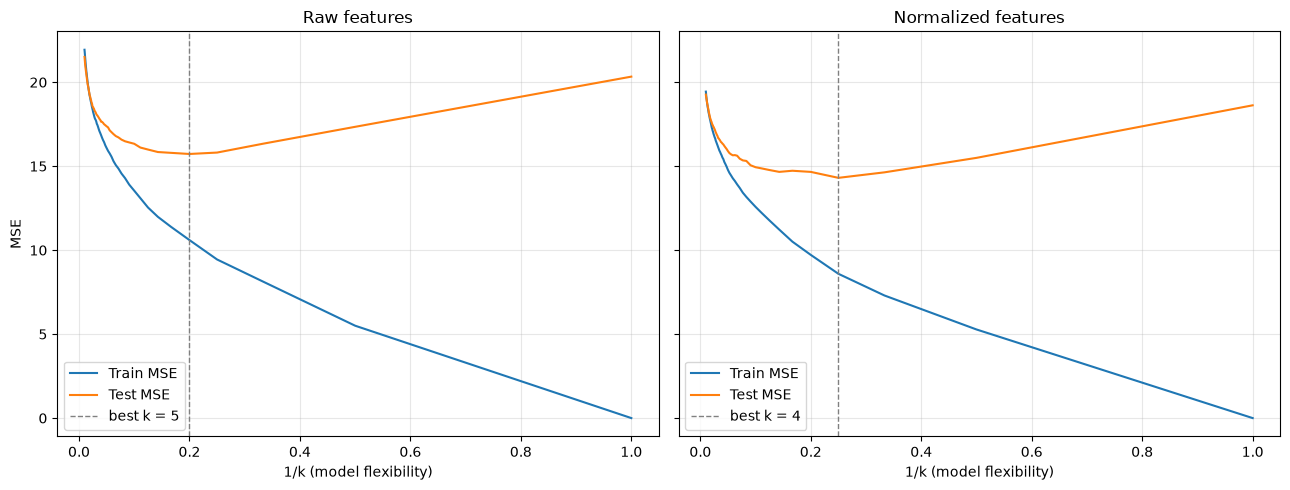

In [20]:
inv_k = [1 / k for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, name in zip(axes, ["Raw", "Normalized"]):
    tr, te, bk, bm = knn_results[name]
    ax.plot(inv_k, tr, label="Train MSE")
    ax.plot(inv_k, te, label="Test MSE")
    ax.axvline(1 / bk, color="gray", ls="--", lw=1, label=f"best k = {bk}")
    ax.set_xlabel("1/k (model flexibility)")
    ax.set_title(f"{name} features")
    ax.legend()
    ax.grid(alpha=0.3)
axes[0].set_ylabel("MSE")
fig.tight_layout()
plt.show()

**Setup.** KNN regression was performed on the same 70/30 split used in part
(h), for k ∈ {1, ..., 100}, using both raw and standardized features.
Standardization used `StandardScaler` fit on the training set only and then
applied to both sets, so that no test-set information influences
preprocessing.

**Results.**

| Features | Best k | Test MSE |
|---|---|---|
| Raw | 5 | 15.73 |
| Normalized | 4 | 14.31 |

Normalization improves test MSE by about 9%. The predictors are measured on
very different scales — AP averages roughly 1013 millibar while AT averages
about 19°C — so in the raw feature space Euclidean distance is dominated by
AP, the least informative predictor. Standardizing places all four features
on comparable scales so that each contributes proportionally to the distance
calculation.

**Interpretation of the plot.** Errors are plotted against 1/k, which
measures model flexibility: 1/k = 1 corresponds to k = 1 (maximum
flexibility) and small 1/k corresponds to large k (heavy smoothing).

At k = 1 the training MSE is exactly zero, since every training point is its
own nearest neighbor and is predicted perfectly, while the test MSE is
substantially higher. This is overfitting. As k increases the model smooths,
training error rises, and test error falls to a minimum before rising again
as the model becomes too rigid. The optimal k balances these, at k = 4 for
normalized features.

## (j) Comparison with Linear Regression

**Comparison.**

| Model | Test MSE |
|---|---|
| Linear regression, all predictors (1h Model 1) | 21.24 |
| Linear regression, reduced interaction + quadratic (1h Model 2) | 18.66 |
| KNN regression, raw features, k = 5 | 15.73 |
| **KNN regression, normalized features, k = 4** | **14.31** |

**Analysis.** KNN regression with normalized features outperforms the best
linear model, reducing test MSE from 18.66 to 14.31, an improvement of
roughly 23%. Even KNN on raw features beats both linear models.

This is consistent with what parts (f) and (g) established. Both found
statistically significant nonlinearity and interaction effects, meaning the
true relationship between the ambient variables and power output is not
additive and linear. The linear model in (h) addressed this only partially,
through a fixed set of quadratic and pairwise interaction terms chosen in
advance. KNN imposes no functional form at all — it estimates the response
locally by averaging nearby observations — so it can capture curvature and
interaction of any shape without being told what to look for.

The dataset also favors KNN structurally. With 9,568 observations in only
four dimensions, the training data is dense, so a query point's nearest
neighbors are genuinely close and their average is a good local estimate.
KNN degrades badly in high dimensions, where neighbors become far apart, but
that is not a concern here.

**Tradeoffs.** The linear models remain more interpretable. A coefficient of
−1.98 on AT states directly that output falls about 1.98 MW per °C, whereas
KNN produces no coefficients and offers no explanation of *why* a prediction
was made. Linear regression also supports inference — the p-values used
throughout parts (c) through (h) — while KNN supports only prediction.
Finally, KNN stores the entire training set and computes distances at
prediction time, which is more expensive than evaluating a fitted linear
equation.

**Conclusion.** For pure predictive accuracy on this dataset, KNN regression
with normalized features and k = 4 is the best model. If the goal were
understanding how each ambient variable affects output, the linear model
would be preferable despite its higher error.

### Problem 2 — ISLR Exercise 2.4.1

**(a) n large, p small:** Flexible is **better**. Large n keeps variance low,
so the reduced bias comes at little cost.

**(b) p large, n small:** Flexible is **worse**. Too little data to fit a
flexible model reliably — it overfits.

**(c) Highly non-linear relationship:** Flexible is **better**. An inflexible
method imposes the wrong functional form, producing high bias.

**(d) σ² extremely high:** Flexible is **worse**. It fits the noise rather
than the signal, inflating variance.

### Problem 3 — ISLR Exercise 2.4.7

**(a)** Distances from (0,0,0), since each is √(X₁²+X₂²+X₃²):

| Obs | Y | Distance |
|---|---|---|
| 5 | Green | √2 ≈ 1.414 |
| 6 | Red | √3 ≈ 1.732 |
| 2 | Red | 2.000 |
| 4 | Green | √5 ≈ 2.236 |
| 1 | Red | 3.000 |
| 3 | Red | √10 ≈ 3.162 |

**(b) K = 1: Green.** The nearest point is Obs 5 (√2), which is Green.

**(c) K = 3: Red.** The three nearest are Obs 5 (Green), Obs 6 (Red), Obs 2
(Red) — majority Red, 2/3.

**(d) Small K.** Small K gives a flexible boundary that can follow a
non-linear shape; large K smooths toward a linear boundary and would miss it.